# Automatic laser lock — downhill hunt

**Does not replace** `Automatic_Laser_Lock_PyRPL_Master.ipynb`. That file is the working coarse → triplet → fine sequence.

This notebook: coarse survey to confirm the triplet, then one **slow downhill hunt**. Start above **peak 3**, use that S-curve as a landmark, catch **peak 2**’s zero-crossing, freeze the ASG, optionally close PI.

The hunt is Python + sampler + `hold_dc` steps, not an interrupted analog ramp. Stock PyRPL cannot hardware-catch a zero-crossing.

The Koheron diode must already be on (`Laser_Power.ipynb`); this notebook does not turn it on or off.


In [1]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from laserlock import (
    LaserDrive,
    apply_pid,
    configure_dither,
    connect,
    disengage_lock,
    ensure_dither,
    hunt_peak2_downhill,
    open_pid,
    sample_lock_signals,
    set_iq_phase,
    silence_feedback,
)
from laserlock.peaks import analyze_spectrum, plot_peak_analysis


In [2]:
# ------------------------------------------------------------
# User settings — edit here
# ------------------------------------------------------------

HOSTNAME = "rp-f0c970.local"
PYRPL_CONFIG = "my_config"
RELOAD_FPGA = True

IDLE_V = 0.0
LOCK_MIN_V = -1.0
LOCK_MAX_V = +1.0

# Coarse survey (photodiode)
COARSE_START_V = -0.2
COARSE_STOP_V = +0.4
COARSE_SCAN_S = 1.0
COARSE_SETTLE_S = 0.1
CLUSTER_WINDOW_V = 0.08
REL_PROMINENCE = 0.12
MAX_COARSE_RETRIES = 4

# Hunt: skip peak 3, walk until peak-2 error goes slightly past zero,
# step back onto that zero, freeze, engage PID.
# Extra 20 mV above peak 3 so the start does not clip it (last run did).
HUNT_START_ABOVE_P3_V = 0.095
HUNT_STOP_BELOW_P2_V = 0.020
HUNT_DURATION_S = 60.0

# Internals — leave these
HUNT_STEP_V = 0.0002
HUNT_SAMPLE_T = 0.01
HUNT_GAP_V = 0.025
HUNT_ARM_ABOVE_P3_V = 0.090
HUNT_CATCH_WINDOW_V = 0.040

# Dither / IQ
DITHER_FREQUENCY_HZ = 20_000.0
DITHER_AMPLITUDE_V = 0.002
IQ_BANDWIDTH_HZ = 2_000.0
IQ_ACBANDWIDTH_HZ = 1_000.0
LOCKIN_PHASE_DEG = 0.0
QUADRATURE_FACTOR = 10

# PID — applied automatically after the catch. Loopback: P=0, I=-3 Hz.
PID_P = 0.0
PID_I_HZ = -3.0
PID_CORR_MIN_V = -0.20
PID_CORR_MAX_V = +0.20

print(
    f"Hunt starts {1e3 * HUNT_START_ABOVE_P3_V:.0f} mV above survey peak 3, "
    f"stops {1e3 * HUNT_STOP_BELOW_P2_V:.0f} mV below peak 2, "
    f"then PID P={PID_P:g} I={PID_I_HZ:g} Hz."
)


Hunt starts 95 mV above survey peak 3, stops 20 mV below peak 2, then PID P=0 I=-3 Hz.


In [3]:
# ------------------------------------------------------------
# Connect
# ------------------------------------------------------------

p, rp = connect(
    hostname=HOSTNAME,
    config=PYRPL_CONFIG,
    reloadfpga=RELOAD_FPGA,
    gui=False,
)
drive = LaserDrive(rp, idle_v=IDLE_V)
drive.enable_idle()
print(f"ASG points {drive.asg.data_length},  scope points {drive.scope.data_length}")


INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /Users/brandon/pyrpl_user_dir/config/my_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe my_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('my_config')
in a python terminal.


Connecting to Red Pitaya...
  hostname:    rp-f0c970.local
  config:      my_config
  user_dir:    /Users/brandon/Documents/Python Scripts/Grok Laser/pyrpl_data
  reloadfpga:  True
  Flashing the PyRPL FPGA (stock Red Pitaya image will not work). ~10 s...


INFO:pyrpl.redpitaya:Found FPGA binfile at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname rp-f0c970.local.


  FPGA overlay file: cat /tmp/loaded_fpga.inf
Connected. Analog outputs are disconnected until the laser drive enables OUT1.
OUT1 enabled, parked at +0.0000 V.
Scope warmup: 32768 samples (discarded)
ASG points 16384,  scope points 16384


## AOM on OUT2

Continuous sine on **OUT2** (`asg1`) for the AOM. Independent of the OUT1 / IN1 lock path. Stays on until **Shutdown**.

`AOM_AMPLITUDE_V` is peak volts (max 1.0). Change amp/freq in the next cell.


In [4]:
# ------------------------------------------------------------
# AOM drive — OUT2 / asg1. Leave running until shutdown.
# ------------------------------------------------------------

AOM_FREQUENCY_HZ = (115.325/4)*1e6
AOM_AMPLITUDE_V = 1.0  # peak volts, max 1.0

drive.start_aom(AOM_FREQUENCY_HZ, AOM_AMPLITUDE_V)


AOM OUT2: 28.831250 MHz  (requested 28.831250 MHz)  amp 1.0000 V peak  output_direct=out2


## Coarse scan

Confirm the L→R triplet is in range. Peak 3 (rightmost) is the hunt landmark; peak 2 is the lock target.



------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.2000 V
Scan:      -0.200000 -> +0.400000 V
Scan time: 1.000 s
ASG period: 8.590 s   scope window 2.147 s  (decimation 16384)
Pause:     0.100 s
Holding +0.0000 V
Scan samples: 6943  (raw window 7019)
Kept voltage: -0.193996 -> +0.352045 V  (requested -0.200000 -> +0.400000 V)
Now holding:  +0.000000 V


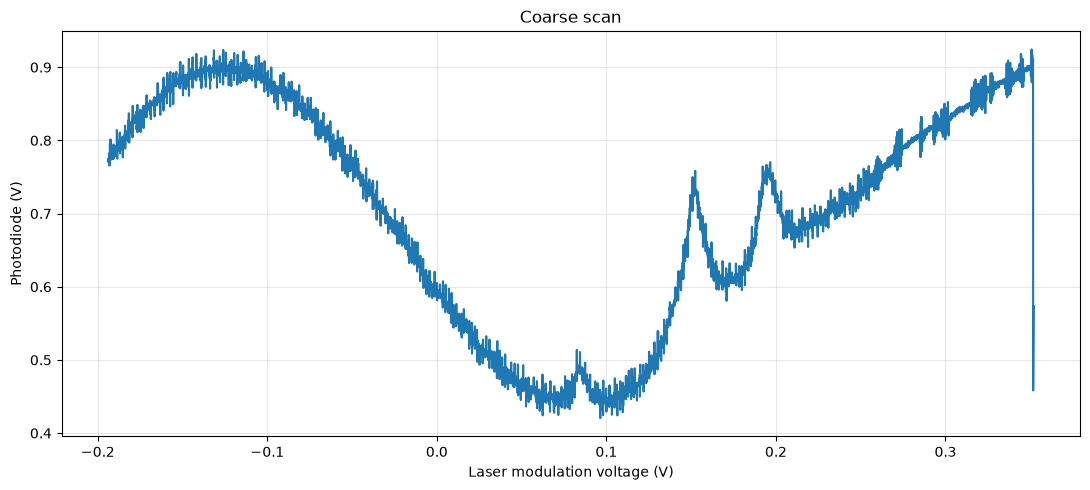

In [5]:
# ------------------------------------------------------------
# Coarse scan
# ------------------------------------------------------------

silence_feedback(rp)
coarse_x, coarse_pd, coarse_plan, coarse_full = drive.quick_scan(
    start_v=COARSE_START_V,
    stop_v=COARSE_STOP_V,
    scan_time=COARSE_SCAN_S,
    pause_s=COARSE_SETTLE_S,
)

plt.figure(figsize=(11, 5))
plt.plot(coarse_x, coarse_pd)
plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode (V)")
plt.title("Coarse scan")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Triplet (left to right):
  1: +0.083811 V   prom 0.04941
  2: +0.152031 V   prom 0.1795
  3: +0.195292 V   prom 0.1174
Landmark peak 3: +0.195292 V
Target    peak 2: +0.152031 V


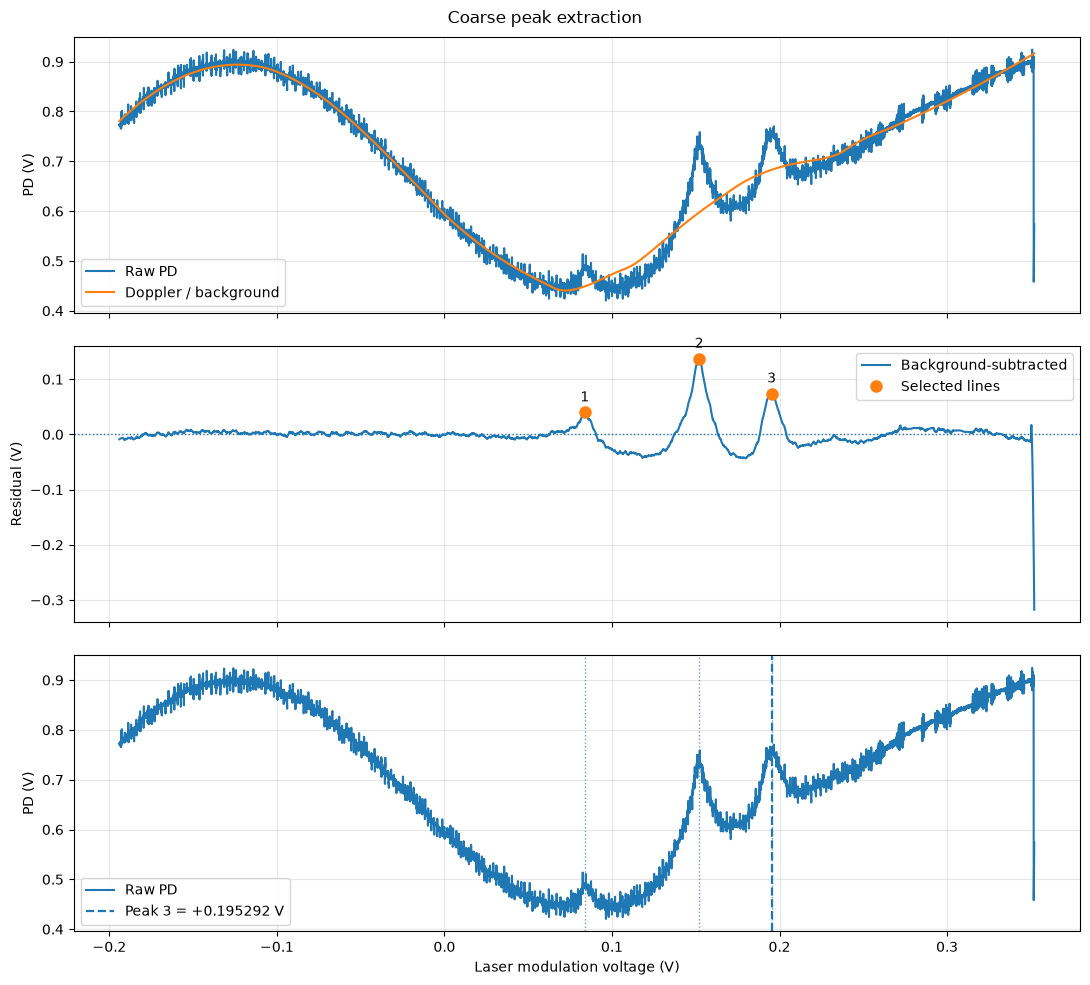

In [6]:
# ------------------------------------------------------------
# Coarse peak ID
# ------------------------------------------------------------

analysis = None
for attempt in range(1, MAX_COARSE_RETRIES + 1):
    if attempt > 1:
        print(f"Attempt {attempt}: no triplet. Rescanning.")
        coarse_x, coarse_pd, coarse_plan, coarse_full = drive.quick_scan(
            start_v=COARSE_START_V,
            stop_v=COARSE_STOP_V,
            scan_time=COARSE_SCAN_S,
            pause_s=COARSE_SETTLE_S,
        )
    analysis = analyze_spectrum(
        coarse_x,
        coarse_pd,
        peak_choice=3,
        cluster_window_v=CLUSTER_WINDOW_V,
        rel_prominence=REL_PROMINENCE,
    )
    if analysis["ok"]:
        break
else:
    plot_peak_analysis(coarse_x, coarse_pd, analysis, title="Coarse — triplet not found")
    raise RuntimeError("Coarse scan did not show three sub-Doppler peaks.")

p1, p2, p3 = analysis["triplet"]
print("Triplet (left to right):")
for pk in analysis["triplet"]:
    print(f"  {pk['label']}: {pk['voltage']:+.6f} V   prom {pk['prominence']:.4g}")
print(f"Landmark peak 3: {p3['voltage']:+.6f} V")
print(f"Target    peak 2: {p2['voltage']:+.6f} V")
plot_peak_analysis(coarse_x, coarse_pd, analysis, title="Coarse peak extraction")


## Downhill hunt

Starts **95 mV above survey peak 3**. The first PD-peak S-curve downhill is
**peak 3** (even if its voltage is higher than the uphill survey — hysteresis).
The next PD peak is **peak 2**. Error past zero on that peak, step back, PID.
Valley zeros between the lines (low PD) are ignored.

Re-run User settings if you changed knobs. The PID cell below is only for
re-tune (P / I / phase) after this catch.


In [7]:
# ------------------------------------------------------------
# Hunt: pass peak 3, catch peak 2, step back, engage PID
# ------------------------------------------------------------

v_start = min(LOCK_MAX_V, float(p3["voltage"]) + float(HUNT_START_ABOVE_P3_V))
v_stop = max(LOCK_MIN_V, float(p2["voltage"]) - float(HUNT_STOP_BELOW_P2_V))
if v_start <= v_stop + 1e-6:
    raise ValueError(
        f"Hunt start {v_start:+.4f} V must be above stop {v_stop:+.4f} V (downhill)."
    )
span_v = v_start - v_stop
hunt_rate_v_s = span_v / float(HUNT_DURATION_S)
arm_below_v = min(v_start - 0.002, float(p3["voltage"]) + float(HUNT_ARM_ABOVE_P3_V))
p3p2 = abs(float(p3["voltage"]) - float(p2["voltage"]))
max_after_landmark_v = p3p2 + 0.030
print(f"Hunt window {v_start:+.6f} → {v_stop:+.6f} V  (OUT1 decreasing)")
print(f"  survey peak 3 {p3['voltage']:+.6f} V (skip),  survey peak 2 {p2['voltage']:+.6f} V (lock)")
print(
    f"  start is {1e3 * (v_start - p3['voltage']):.0f} mV above peak 3;  "
    f"span {1e3 * span_v:.1f} mV in ~{HUNT_DURATION_S:.0f} s  "
    f"({1e3 * hunt_rate_v_s:.2f} mV/s)"
)
print(
    f"  ignore until {arm_below_v:+.6f} V;  "
    f"after landmark ≤ {1e3 * max_after_landmark_v:.0f} mV"
)

silence_feedback(rp)
configure_dither(
    rp,
    frequency_hz=DITHER_FREQUENCY_HZ,
    amplitude_v=DITHER_AMPLITUDE_V,
    bandwidth_hz=IQ_BANDWIDTH_HZ,
    acbandwidth_hz=IQ_ACBANDWIDTH_HZ,
    phase_deg=LOCKIN_PHASE_DEG,
    quadrature_factor=QUADRATURE_FACTOR,
    pid_corr_min_v=PID_CORR_MIN_V,
    pid_corr_max_v=PID_CORR_MAX_V,
)

det, hunt_log = hunt_peak2_downhill(
    drive,
    rp,
    v_start=v_start,
    v_stop=v_stop,
    step_v=HUNT_STEP_V,
    rate_v_s=hunt_rate_v_s,
    sample_t=HUNT_SAMPLE_T,
    n_skip=1,
    gap_dv=HUNT_GAP_V,
    arm_below_v=arm_below_v,
    max_after_landmark_v=max_after_landmark_v,
    catch_hint_v=p2["voltage"],
    catch_window_v=HUNT_CATCH_WINDOW_V,
    landmark_hint_v=p3["voltage"],
)

if det.state != "caught":
    lock_voltage = None
    print("Hunt did not catch peak 2. Inspect the overlay; PID stays open.")
else:
    lock_voltage = float(det.v_lock if det.v_lock is not None else det.v_catch)
    print(f"Frozen at {drive.current_v:+.6f} V  (error zero {det.v_catch:+.6f} V)")
    sig0 = sample_lock_signals(rp, t=0.05)
    print(
        f"Before PID  asg0={drive.current_v:+.6f}  out1={sig0['out1']:+.4f}  "
        f"err={sig0['error']:+.4f}  PD={sig0['pd']:+.4f}"
    )
    if abs(sig0["error"]) > 0.01:
        print("  WARNING: error is not near 0 at park — PID will servo to a different zero.")
    apply_pid(
        rp,
        p=PID_P,
        i_hz=PID_I_HZ,
        corr_min_v=PID_CORR_MIN_V,
        corr_max_v=PID_CORR_MAX_V,
        phase_deg=LOCKIN_PHASE_DEG,
        monitor_s=2.4,
    )


Hunt window +0.290292 → +0.132031 V  (OUT1 decreasing)
  survey peak 3 +0.195292 V (skip),  survey peak 2 +0.152031 V (lock)
  start is 95 mV above peak 3;  span 158.3 mV in ~60 s  (2.64 mV/s)
  ignore until +0.285292 V;  after landmark ≤ 73 mV
Dither on, PID open.
  0.0020 V @ 20000.0 Hz, phase 0.0 deg
Holding +0.2903 V
Hunt start +0.290292 V → stop +0.132031 V  (OUT1 decreasing)
  order: start → skip peak 3 → catch peak 2 (lock target)
  step 0.20 mV,  rate 2.64 mV/s,  0.076 s/step
  ignore features until +0.285292 V
  after peak 3, stop within 73 mV (do not crawl through peak 1)
  wing PD +0.6992 V,  err thresh 2.36 mV
  approach    V=+0.290292  err=+0.0074  PD=+0.7019
  armed      V=+0.285292  err thresh 3.79 mV  (was Doppler; now near peak 3)
  search      V=+0.285292  err=+0.0086  PD=+0.6826
  search      V=+0.280292  err=+0.0030  PD=+0.6789
  lobe        V=+0.276492  err=-0.0279  PD=+0.7010
  search      V=+0.276092  err=-0.0195  PD=+0.6921
  search      V=+0.275292  err=+0.0055

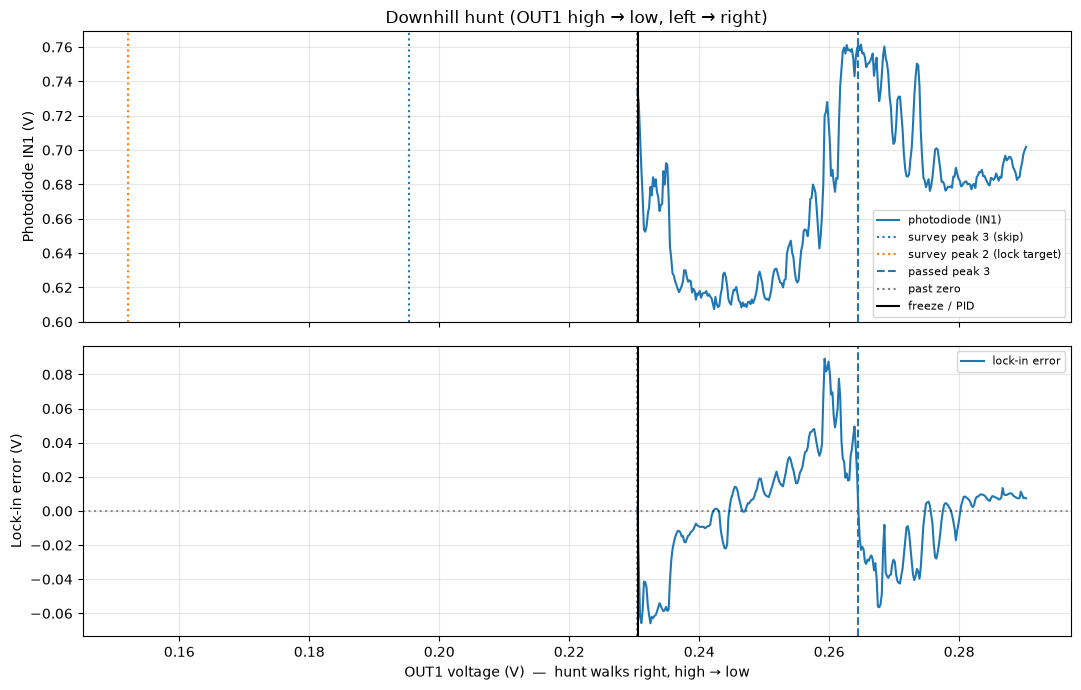

In [8]:
# ------------------------------------------------------------
# Hunt overlay (after freeze)
# ------------------------------------------------------------

hv = np.array([row["voltage"] for row in hunt_log])
he = np.array([row["error"] for row in hunt_log])
hpd = np.array([row["pd"] for row in hunt_log])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(hv, hpd, label="photodiode (IN1)")
axes[0].axvline(p3["voltage"], linestyle=":", color="C0", label="survey peak 3 (skip)")
axes[0].axvline(p2["voltage"], linestyle=":", color="C1", label="survey peak 2 (lock target)")
if det.v_landmark is not None:
    axes[0].axvline(det.v_landmark, linestyle="--", color="C0", label="passed peak 3")
if getattr(det, "v_overshoot", None) is not None:
    axes[0].axvline(det.v_overshoot, linestyle=":", color="0.5", label="past zero")
if lock_voltage is not None:
    axes[0].axvline(lock_voltage, linestyle="-", color="k", label="freeze / PID")
axes[0].set_ylabel("Photodiode IN1 (V)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Downhill hunt (OUT1 high → low, left → right)")
axes[0].invert_xaxis()

axes[1].plot(hv, he, label="lock-in error")
axes[1].axhline(0.0, linestyle=":", color="k", alpha=0.4)
if det.v_landmark is not None:
    axes[1].axvline(det.v_landmark, linestyle="--", color="C0")
if getattr(det, "v_overshoot", None) is not None:
    axes[1].axvline(det.v_overshoot, linestyle=":", color="0.5")
if lock_voltage is not None:
    axes[1].axvline(lock_voltage, linestyle="-", color="k")
axes[1].set_xlabel("OUT1 voltage (V)  —  hunt walks right, high → low")
axes[1].set_ylabel("Lock-in error (V)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()
plt.tight_layout()
plt.show()


## PID re-tune

The hunt cell already closed the loop (P=0, I=−3 Hz). Use this only to change
P / I / phase. Open PID first if you need to drop the loop; do not Open PID
if you want it to stay locked.


In [9]:
# ------------------------------------------------------------
# PID re-tune — change knobs, re-run. Stays on after this cell.
# ------------------------------------------------------------

LOCKIN_PHASE_DEG = 0.0
PID_P = 0.0
PID_I_HZ = -3.0

open_pid(rp)
apply_pid(
    rp,
    p=PID_P,
    i_hz=PID_I_HZ,
    corr_min_v=PID_CORR_MIN_V,
    corr_max_v=PID_CORR_MAX_V,
    phase_deg=LOCKIN_PHASE_DEG,
    monitor_s=2.4,
)


PID open. Dither still on; ASG still at the park.
IQ phase 0.0 deg
Dither: 0.0020 V @ 20000 Hz  output_direct=out1  on=True
  OUT1 while parked: std 1.44 mV,  ptp 3.78 mV  (2 mV amp dither is ~4 mVpp if present)
PID on  P=0  I=-3.00155 Hz  phase=0.0 deg
t     ival      out1      err       PD
0.4  +0.0099  +0.2405  +0.0011  +0.6099
0.8  +0.0186  +0.2489  -0.0011  +0.6095
1.2  +0.0111  +0.2417  +0.0010  +0.6087
1.6  +0.0164  +0.2469  -0.0006  +0.6099
2.0  +0.0178  +0.2483  -0.0006  +0.6104
2.4  +0.0106  +0.2414  +0.0012  +0.6081


In [10]:
# ------------------------------------------------------------
# Open PID — dither and park unchanged
# ------------------------------------------------------------

#open_pid(rp)


In [11]:
# ------------------------------------------------------------
# Shutdown — zeros PID/IQ, slews ASG to 0 V, disconnects OUT1
# ------------------------------------------------------------

#drive.shutdown()
